<a href="https://colab.research.google.com/github/sergejlembke/aki-ml/blob/main/p7/22_CNN_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Machine Learning
### Sommersemester 2026
Prof. Dr. Stefan Goetze

# CNN mit Keras: Hausnummern erkennen

In dieser Aufgabe wollen verwenden wir erneut den Datensatz, der Bildausschnitte mit einzelnen Ziffern von Hausnummern enthält.
Wir sind also wieder bei dem Problem der Klassifikation von Ziffern auf Grundlage von Bildern, wie schon beim klassischen MNIST Datensatz.
Da es sich aber hier um (Farb-) Fotos handelt, die zudem noch recht verrauscht sind, ist das Problem, die Ziffern zu erkennen, aber deutlich schwieriger.

Wir laden zunächst die Bidler von der URL http://ufldl.stanford.edu/housenumbers herunter.
Details zum Datensatz finden Sie in [1].

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
print("Lade Tensorflow in Version", tf.__version__)
from packaging import version
assert version.parse(tf.__version__) > version.parse("2.3.0"), \
    "TF 2.3.0 hat einen Bug beim Speichern und Laden von Modellen. Siehe [2]"
import os
import tarfile
import urllib.request


# download dataset
url = [f"http://ufldl.stanford.edu/housenumbers/{n}_32x32.mat" for n in ("train", "test")]
dfile = [f"./{n}_32x32.mat" for n in ("train", "test")]


for i in range(len(url)):
    if not os.path.isfile(dfile[i]):
        print("Downloading file " + str(dfile[i]) + " from " + str(url[i]))
        urllib.request.urlretrieve(url[i], dfile[i])

Lade Tensorflow in Version 2.20.0


Die Daten liegen im `.mat`-Format vor, dass zumeist in Matlab verwendet wird.
Wir importieren die Daten über die Funktion `scipy.io.loadmat` und extrahieren dann die Attribute und Labels jeweils aus den Test- und Trainings-Daten.

In [2]:
from scipy.io import loadmat
train_raw = loadmat('./train_32x32.mat')
test_raw = loadmat('./test_32x32.mat')

train_images = np.array(train_raw['X'])
test_images = np.array(test_raw['X'])

train_labels = train_raw['y']
test_labels = test_raw['y']

print(train_images.shape)
print(test_images.shape)

(32, 32, 3, 73257)
(32, 32, 3, 26032)


Wenn Sie sich die Dimension der Datensätze ansehen, stellen Sie fest, dass die Daten unpassend strukturiert sind.
In den ersten Dimensionen haben wir die (RGB) Pixel der einzelnen Bilder, in der letzten Dimension die einzelnen Bilder.
Daher sortieren wir die Dimensionen, bzw. die Axen unserer Datensätze um, sodass die erste Dimension dem Index eines Bildes entspricht.

In [3]:
# Fix the axes of the images

train_images = np.moveaxis(train_images, -1, 0)
test_images = np.moveaxis(test_images, -1, 0)

print(train_images.shape)
print(test_images.shape)

(73257, 32, 32, 3)
(26032, 32, 32, 3)


Nun können wir ein zufälliges Bild ausgeben:

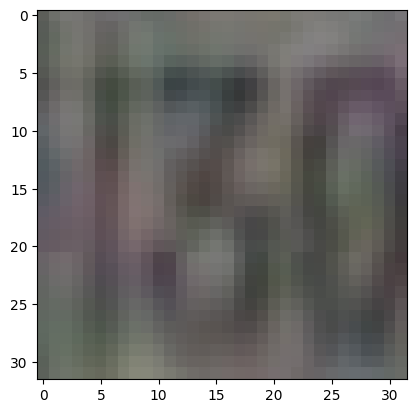

Label:  [3]


In [38]:
import matplotlib.pyplot as plt
import random
# Plot a random image and its label
randImgID = random.randint(0,len(train_images))
plt.imshow(train_images[randImgID])
plt.show()

print('Label: ', train_labels[randImgID])

In [39]:
train_images = train_images.astype('float64')
test_images = test_images.astype('float64')

train_labels = train_labels.astype('int64')
test_labels = test_labels.astype('int64')

print("Minimum value of train set (before normalisation): " + str(np.min(train_images)))
print("Maximum value of test set (before normalisation): " + str(np.max(test_images)))

train_images /= 255.0
test_images /= 255.0

print("Minimum value of train set (after normalisation): " + str(np.min(train_images)))
print("Maximum value of test set (after normalisation): " + str(np.max(test_images)))

train_labels -= 1
test_labels -= 1

Minimum value of train set (before normalisation): 0.0
Maximum value of test set (before normalisation): 255.0
Minimum value of train set (after normalisation): 0.0
Maximum value of test set (after normalisation): 1.0


In [40]:
#print("Shape of train_labels: " + str(train_labels.shape))
#print("Shape of test_labels: " + str(test_labels.shape))

train_labels = train_labels.squeeze()
test_labels = test_labels.squeeze()

#print("Shape of train_labels: " + str(train_labels.shape))
#print("Shape of test_labels: " + str(test_labels.shape))

Wir stellen nun ein sequenziellen Keras Model auf. Das Modell hat 2 Schichten.
Die erste Schicht besitzt 128 Neuronen und verwendet ReLU als Aktivierungsfunktion.
Die zweite Schicht besitzt 10 Neuronen und verwendet als Aktivierungsfunktion die Softmax-Funktion.

In [41]:
#Modell definieren

def create_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(32, 32, 3)))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    return model

model = create_model()

Nun wählen wir geeignete Parameter für das Modell aus

In [42]:
#Modellparameter
optimizer =  'sgd'
loss = 'sparse_categorical_crossentropy'
metrics = ['accuracy']

Nun können wir das Modell trainieren.

In [43]:
mname = "mlp_model.keras"

if not os.path.exists(mname):
    print("Neues Modell anlegen!")
    model = create_model()
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
else:
    print("Load Model from file", mname)
    model = tf.keras.models.load_model(mname)

history = model.fit(train_images, train_labels, epochs=5)
model.save(mname)


Neues Modell anlegen!
Epoch 1/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2766 - loss: 2.0821
Epoch 2/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5048 - loss: 1.5667
Epoch 3/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6032 - loss: 1.3016
Epoch 4/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6440 - loss: 1.1756
Epoch 5/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6676 - loss: 1.0979


In [44]:
# Trainiertes Modell auswerten
model = tf.keras.models.load_model(mname)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Classification Accuracy (Test):', test_acc)

814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5385 - loss: 1.4036
Classification Accuracy (Test): 0.538452684879303


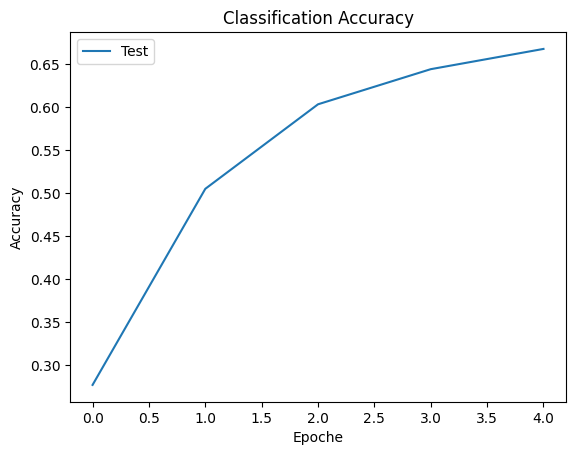

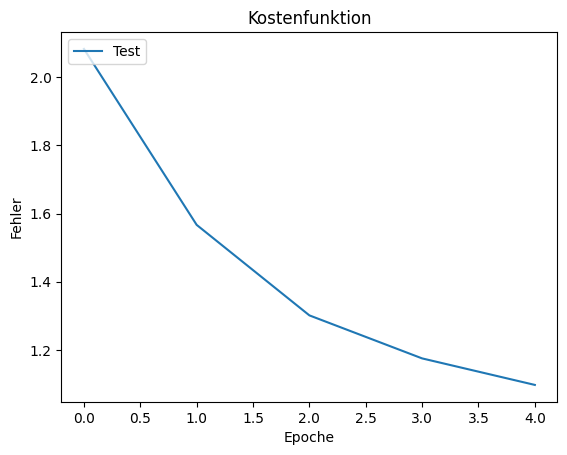

In [45]:
import matplotlib.pyplot as plt

def plot_history(history):
    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.title('Classification Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoche')
    plt.legend(['Test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.title('Kostenfunktion')
    plt.ylabel('Fehler')
    plt.xlabel('Epoche')
    plt.legend(['Test'], loc='upper left')
    plt.show()

plot_history(history)

<div class="alert alert-block alert-info">
    
**Aufgabe:** Erstellen Sie ein Faltungsnetz (CNN) mit folgenden Schichten über die [*Keras Sequential API*](https://keras.io/api/models/sequential/):

1. Die erste Schicht soll ein `Conv2D`-Layer sein. Sie benötigen keinen zusätzlichen `Flatten`-Layer. Statt dessen können Sie die Dimension als `shape`-Parameter einem [`Input()`-Objekt](https://keras.io/guides/sequential_model/) übergeben. Verwenden Sie in der ersten Schicht einfach den Parameter `Input(shape=(...))` und setzen Sie ihn auf das 3-Tupel `(32, 32, 3)` (32x32 Pixel im RGB Format). Die [`Conv2D`](https://keras.io/api/layers/convolution_layers/convolution2d/)-Schicht soll $16$ Filtermasken einer Größe von $3\times{}3$ Pixeln verwenden. Als Aktivierungsfunktion verwenden Sie `relu`.
2. Die zweite Schicht ist ein Pooling-Layer. Fassen Sie immer $2\times{}2$ Pixel mit Max-Pooling ([`MaxPooling2D`](https://keras.io/api/layers/pooling_layers/max_pooling2d/)) zusammen.
3. Um Overfitting zu vermeiden, führen wir ein Dropout-Layer ein. Verwenden die eine Dropout-Rate von 30%.
4. Fügen Sie je eine weitere `Conv2D`, `MaxPooling2D` und `Dropout` Schicht ein. Die Parameter sollen wie bei 1.-3. gewählt werden, mit der Ausnahme, dass die `Conv2D`-Schicht nun doppelt so viele (also 32) Filtermasken verwenden soll.
5. Transformieren Sie die 2D-Daten in 1D- Daten mit einem `Flatten`-Layer. `Flatten` benötigt keine Parameter.
6. Fügen Sie dem Modell eine voll-vermaschte Schicht (`Dense`) mit 256 Neuronen hinzu. Als Aktivierungsfunktion soll hier acuh `relu` verwendet werden.
7. Fügen Sie ein Dropout Schicht mit 30% Dropout rate ein
8. Fügen Sie dem Modell einen Eine Ausgabeschicht mit $10$ Neuronen hinzu (`Dense`). Die Aktivierungsfunktion hier sollte `softmax` sein.
</div>

In [46]:
#Modell definieren
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras import Input
def create_model():
    model = keras.Sequential()
    # YOUR CODE HERE
    model.add(Input(shape=(32, 32, 3)))
    model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))
    return model

model = create_model()

Nun trainieren wir das Modell und schreiben die Trainierten Parameter erneut in eine Datei.

(*Hinweis:* Achten Sie darauf, die Datei zu löschen, falls Sie ein neues Modell erzeugt haben)

In [47]:
mname = "cnn_model.keras"

if not os.path.exists(mname):
    print("Neues Modell anlegen!")
    model = create_model()
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
else:
    print("Load Model from file", mname)
    model = tf.keras.models.load_model(mname)

history = model.fit(train_images, train_labels, epochs=5)
model.save(mname)

Neues Modell anlegen!
Epoch 1/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.1873 - loss: 2.2419
Epoch 2/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.1973 - loss: 2.2090
Epoch 3/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.3305 - loss: 1.9359
Epoch 4/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.4821 - loss: 1.5667
Epoch 5/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 76s 33ms/step - accuracy: 0.6204 - loss: 1.1841


Wir können nun das trainierte Modell bewerten.

In [48]:
#Trainiertes Modell auswerten
model = tf.keras.models.load_model(mname)
test_loss, test_acc = model.evaluate (test_images, test_labels)
print('Test accuracy:', test_acc)

814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7584 - loss: 0.9257
Test accuracy: 0.7584127187728882


## Wichtig für Trainings-Evaluation:
Um die Accuracy während des Trainings mit der vom Test besser vergleichen zu können, sollte `model.evaluate()` genutzt werden.

Hintergrund: Die während der Epoche berechneten Accrucacies beginnen anfangs mit weniger guten Gewichten und daher mit schlechterer Acc., und im Verlauf einer Epoche nimmt die Acc. dann zu. Ausgegeben wird der Mittelwert der Acc. über die Epoche. DropOut verstärkt dies zusätzlich, da nicht alle Neuronen genutzt werden.

In [51]:
train_loss, train_acc = model.evaluate(train_images, train_labels, verbose=0)
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.7653466463088989
Test Accuracy : 0.7584127187728882


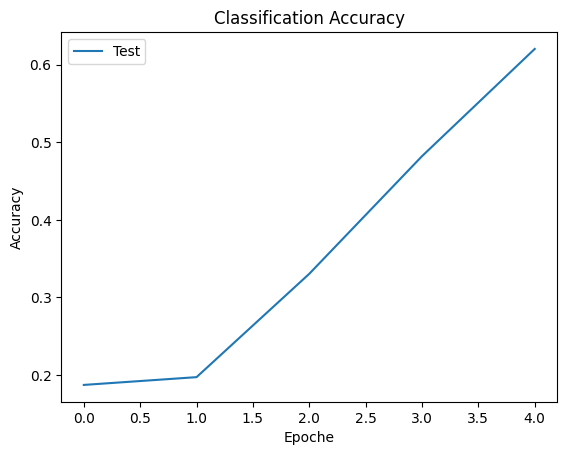

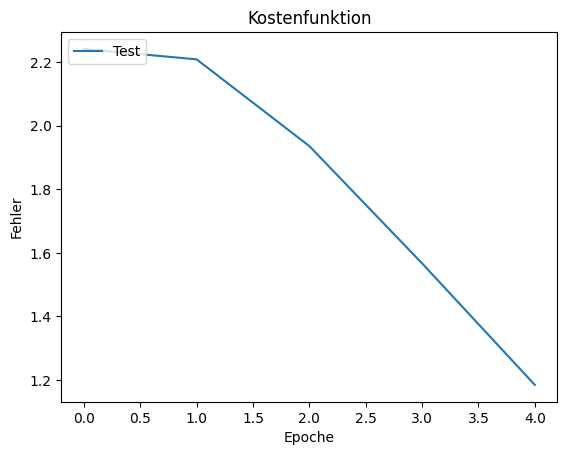

In [49]:
import matplotlib.pyplot as plt

def plot_history(history):
    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.title('Classification Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoche')
    plt.legend(['Test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.title('Kostenfunktion')
    plt.ylabel('Fehler')
    plt.xlabel('Epoche')
    plt.legend(['Test'], loc='upper left')
    plt.show()

plot_history(history)

### Referenzen

[1] Yuval Netzer, Tao Wang, Adam Coates, Alessandro Bissacco, Bo Wu, Andrew Y. Ng. *"Reading Digits in Natural Images with Unsupervised Feature Learning"*,  NIPS Workshop on Deep Learning and Unsupervised Feature Learning 2011.

[2] Tensorflow Github Issue #42459 [Accuracy is lost after save/load #42459](https://github.com/tensorflow/tensorflow/issues/42459)

Beiträge zu diesem Notebook: [Heiner Giefers](https://github.com/hgiefers), [Stefan Goetze](https://github.com/Stefan-Goe)